# Bug Replay simulation
This analysis is about see the effect of bug causing a different value in iob or autosense.

You should download `iobBugInvoke` and `autosensBugInvoke` from xxx, but here's the process of 
creating it from `triodataset`

1. Added glucose trace to feed the simulator, 
   1. Traces are generated by [this notebook](added_glucose.ipynb) 
   2. And this generates the added glucose [this script](Scripts/generate_all_added_glucose.sh)
   3. Added glucose with duration > 24h is [sampled](Scripts/filter_added_glucose.py) and placed into [this folder](iobBugInvoke/sample_added_glucose_trace)
2. initial state where the bugs are triggered
   1. Generated iob states using [this script](Scripts/create_state_from_snap_autosens.py)
   2. Generated autosens states using [this script](Scripts/create_state_from_snap_autosens.py)
   3. each snap shot have their difference and filename noted down [here](autosens-comparison-threshold.json) and [here](iob-comparison-threshold.json). top 100 snap shots are filtered using [this](Scripts/filter_autosens_bugs.py) and [this](Scripts/filter_autosens_bugs.py). (I don't rememeber where the snapshot are comming from?)
3. Run the simulation with [this script](Scripts/run_all_states_all_csvs.sh)

Donwload the date files from xxx, (they should be autosensBugInvoke and iobBugInvoke)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

from ParkesErrorGrid.parkes_error import ParkesError

In [2]:
def get_all_glucose(folder: str) -> pd.Series:
    files = [f for f in os.listdir(folder) if f.endswith('.csv')]
    all_glucose = []
    for file in files:
        stats = pd.read_csv(os.path.join(folder, file))
        all_glucose.append(stats['glucose'])
    return pd.concat(all_glucose, ignore_index=True)

In [3]:
def get_all_glucose_r(root_folder: str, algo: str = 'buggy') -> pd.Series:
    folders = [f for f in os.listdir(root_folder) if os.path.isdir(os.path.join(root_folder, f)) and f.startswith("simOut")]
    all_glucose = []
    for folder in folders:
        folder_path = os.path.join(root_folder, folder, algo)
        all_glucose.append(get_all_glucose(folder_path))
    return pd.concat(all_glucose, ignore_index=True)

## Iob bug invocations

In [4]:
buggy_glucose = get_all_glucose_r('iobBugInvoke/', 'buggy')
fixed_glucose = get_all_glucose_r('iobBugInvoke/', 'fixed')

pkeg1 = ParkesError(buggy_glucose.to_list(), fixed_glucose.to_list())
pkeg2 = ParkesError(fixed_glucose.to_list(), buggy_glucose.to_list())

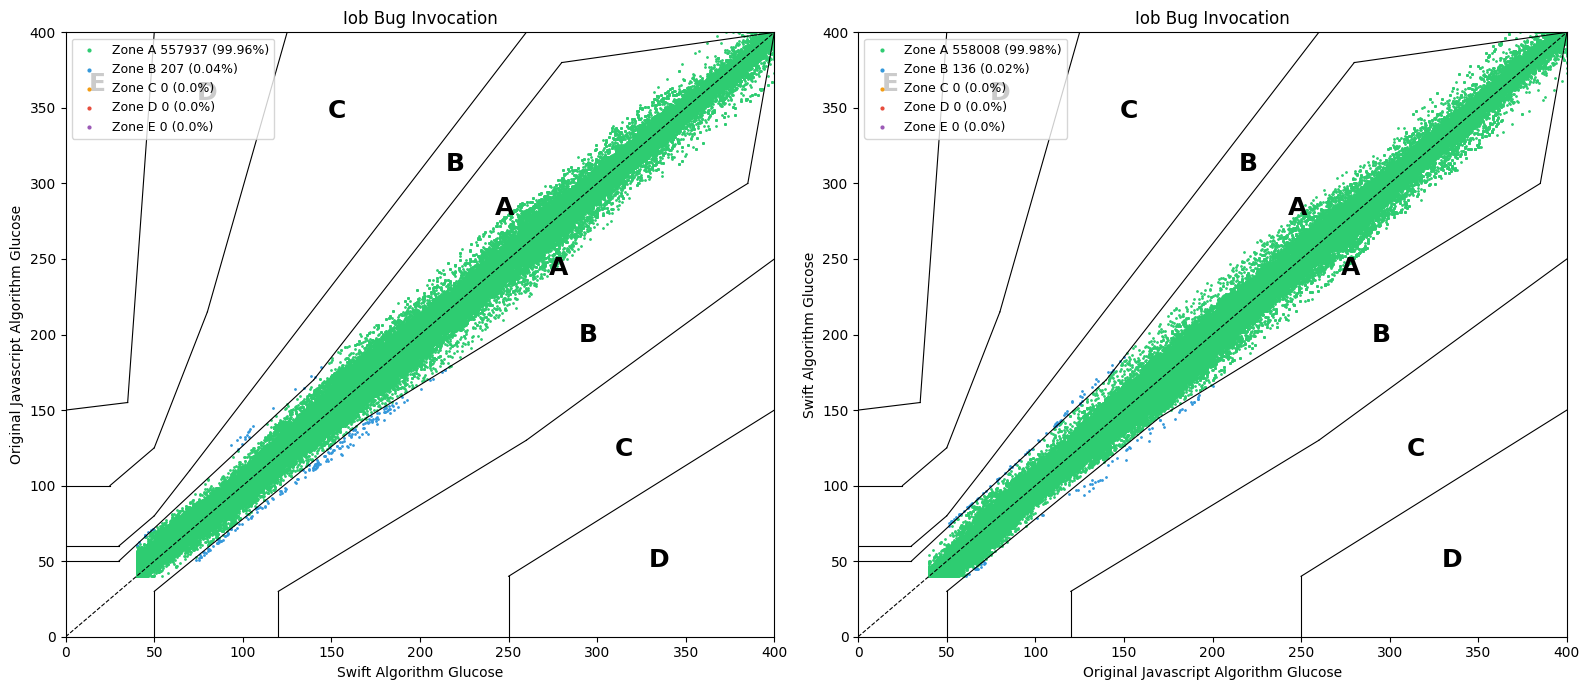

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

pkeg1.plot(title="Iob Bug Invocation", x_axis="Original Javascript Algorithm Glucose", y_axis="Swift Algorithm Glucose", size=1, ax=ax2)
pkeg2.plot(title="Iob Bug Invocation", x_axis="Swift Algorithm Glucose", y_axis="Original Javascript Algorithm Glucose", size=1, ax=ax1)

plt.tight_layout()
plt.show()

## Autosens bug invocations

In [7]:
buggy_glucose = get_all_glucose_r('autosensBugInvoke/', 'buggy')
fixed_glucose = get_all_glucose_r('autosensBugInvoke/', 'fixed')

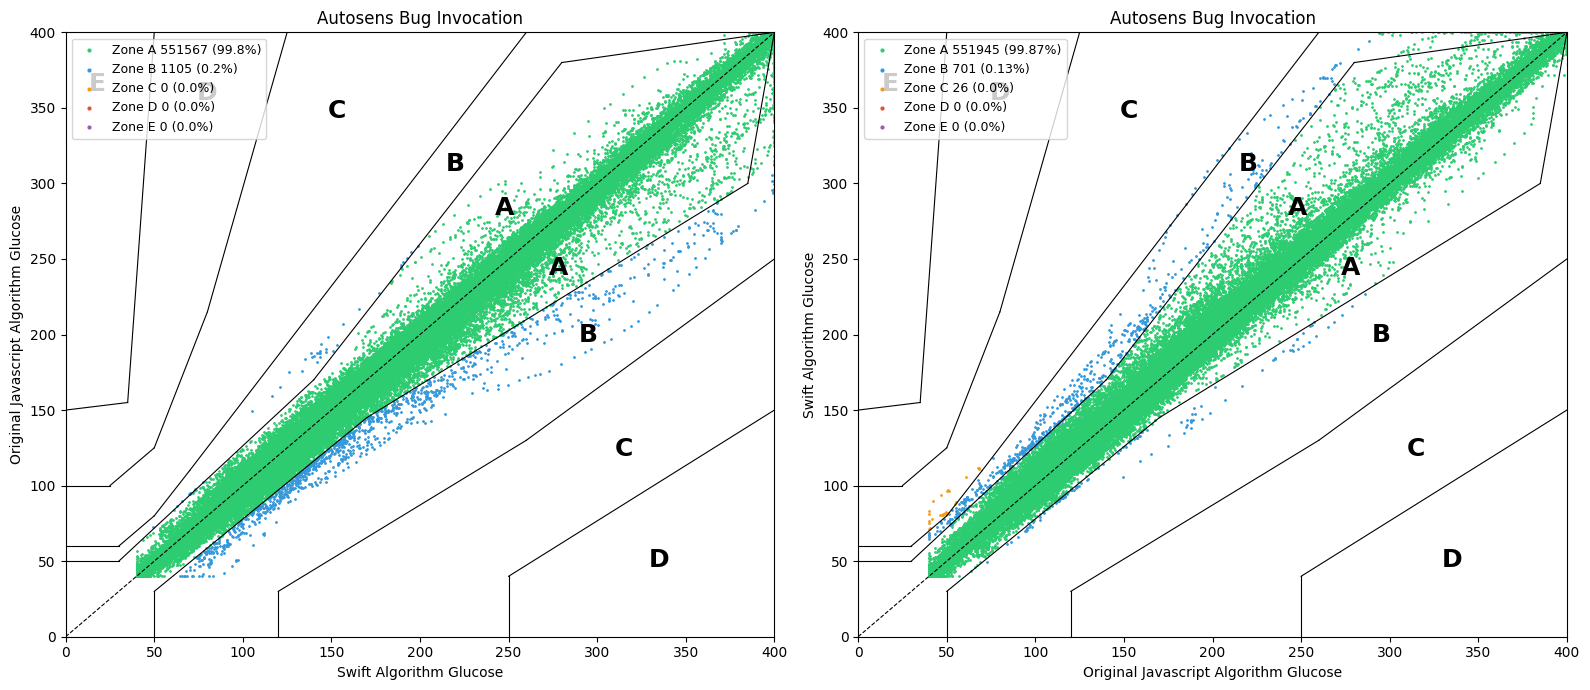

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

pkeg1 = ParkesError(buggy_glucose.to_list(), fixed_glucose.to_list())
pkeg2 = ParkesError(fixed_glucose.to_list(), buggy_glucose.to_list())
pkeg1.plot(title="Autosens Bug Invocation", x_axis="Original Javascript Algorithm Glucose", y_axis="Swift Algorithm Glucose", size=1, ax=ax2)
pkeg2.plot(title="Autosens Bug Invocation", x_axis="Swift Algorithm Glucose", y_axis="Original Javascript Algorithm Glucose", size=1, ax=ax1)

plt.tight_layout()
plt.show()

# Case study

## Autosens

Run the [`single_bug_invoke_run_autosens.sh`](Scripts/single_bug_invoke_run_autosens.sh)

## Iob

Run the [`Single_bug_invoke_run_iob.sh`](Scripts/single_bug_invoke_run_iob.sh)

## Visualize with [plot script](Scripts/plot_glucose.py)
The plot script use a modified simplesim which also have sensitivity logged...?